In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [2]:
# using the same seed for reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ["LOKY_MAX_CPU_COUNT"] = "10"

### Load the data

In [3]:
df = pd.read_csv('train_data.csv')
df.head()

,MW,LogP,NumHDonors,NumHAcceptors,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,pIC50
0,279.273,1.74780,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.000000
1,508.626,4.75440,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.522879
2,317.755,3.45850,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.863279
3,506.606,4.81712,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.040959
4,542.854,5.73340,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000


#### Preparing Features and Target Variables and Checking Their Shapes

In [4]:
X = df.drop('pIC50',  axis=1)
Y = df['pIC50']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (16937, 2052)
Shape of Y: (16937,)


#### Removing low variance features

In [5]:
selection = VarianceThreshold(threshold=(0.02))  
X_var = selection.fit_transform(X)
X_var.shape

(16937, 511)

#### Splliting the data into train and validation (into 80:20)

In [6]:
X_train_us, X_val_us, Y_train_us, Y_val_us = train_test_split(X_var, Y, test_size=0.2, random_state=0)

#### Scalling the data

In [7]:
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train_us)
X_val = scaler_x.transform(X_val_us)

scaler_y = StandardScaler()
Y_train = scaler_y.fit_transform(Y_train_us.values.reshape(-1, 1)).flatten()
Y_val = scaler_y.transform(Y_val_us.values.reshape(-1, 1)).flatten()

print("Shape of X_train:", X_train.shape, "Shape of Y_train:", Y_train.shape)
print("Shape of X_val:", X_val.shape, "Shape of Y_val:", Y_val.shape)

Shape of X_train: (13549, 511) Shape of Y_train: (13549,)
Shape of X_val: (3388, 511) Shape of Y_val: (3388,)


### Simple Neural Network model

A sequential model is defined with a 4 hidden layer of ReLU-activated units and an output layer of 1 unit using linear activation.


In [8]:
model = Sequential()
model.add(keras.Input(shape=(511,)))
model.add(Dense(1230, activation="relu"))
model.add(Dense(760, activation="relu"))
model.add(Dense(400, activation="relu"))
model.add(Dense(200, activation="relu"))
model.add(Dense(1, activation="linear"))
model.summary()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1230)           │       629,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 760)            │       935,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 400)            │       304,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,950,121 (7.44 MB)

 Trainable params: 1,950,121 (7.44 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1230)           │       629,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 760)            │       935,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 400)            │       304,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,950,121 (7.44 MB)

 Trainable params: 1,950,121 (7.44 MB)

 Non-trainable params: 0 (0.00 B)

Defining loss function , optimizer and metrics to track during training

The model is compiled using the SGD optimizer, with mean squared error as the loss function and root mean squared error as the evaluation metric.

In [9]:

model.compile(optimizer=SGD(learning_rate=0.0001), loss='mean_squared_error', metrics=['RootMeanSquaredError', 'r2_score'])

history = model.fit(X_train, Y_train, 
                validation_data=(X_val, Y_val), 
                epochs=300, 
                batch_size=32, 
                verbose=1)

results = model.evaluate(X_val, Y_val)
print('Validation loss, RMSE, R-Squared:', results)

Epoch 1/300
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - RootMeanSquaredError: 0.9969 - loss: 0.9939 - r2_score: -6.6163e-04 - val_RootMeanSquaredError: 0.9862 - val_loss: 0.9725 - val_r2_score: 0.0275
Epoch 2/300
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - RootMeanSquaredError: 0.9695 - loss: 0.9400 - r2_score: 0.0536 - val_RootMeanSquaredError: 0.9640 - val_loss: 0.9293 - val_r2_score: 0.0707
Epoch 3/300
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - RootMeanSquaredError: 0.9471 - loss: 0.8972 - r2_score: 0.0967 - val_RootMeanSquaredError: 0.9443 - val_loss: 0.8918 - val_r2_score: 0.1082
Epoch 4/300
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - RootMeanSquaredError: 0.9270 - loss: 0.8594 - r2_score: 0.1347 - val_RootMeanSquaredError: 0.9263 - val_loss: 0.8580 - val_r2_score: 0.1420
Epoch 5/300
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - RootMeanSquaredError: 0.9084 - loss: 0.8252 - r2_score: 0.1692 - val_RootMeanSquaredError: 0.9096 - val_loss: 0.8274 - val_r2_score: 0.1726
Epoch 6/300
424/424 

Plotting the training curves

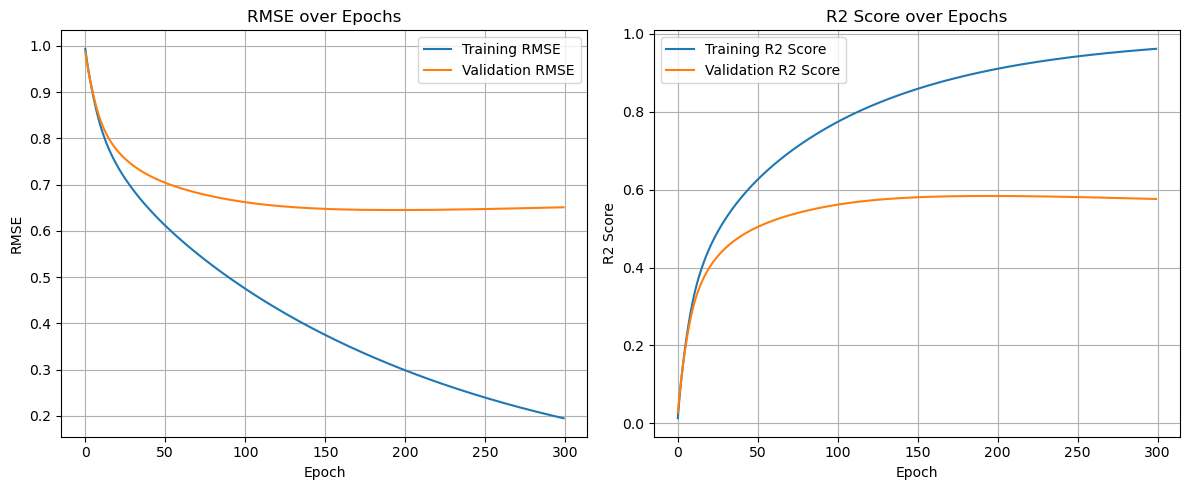

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history['RootMeanSquaredError'], label='Training RMSE')
axes[0].plot(history.history['val_RootMeanSquaredError'], label='Validation RMSE')
axes[0].set_title('RMSE over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['r2_score'], label='Training R2 Score')
axes[1].plot(history.history['val_r2_score'], label='Validation R2 Score')
axes[1].set_title('R2 Score over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R2 Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


Observation :
- It is observed that root mean square error decreased progressively over the training epochs.
- There is a gap between validation rmse and training rmse which show the model is overfitting on the training data. 
- It suggest that the model require some generalization techniques.

### Model with dropout layers

Dropout layers are being added in the model

In [11]:
model_dropout = Sequential()
model_dropout.add(keras.Input(shape=(511,)))
model_dropout.add(Dense(1230, activation="relu"))
model_dropout.add(Dropout(0.3))
model_dropout.add(Dense(760, activation="relu"))
model_dropout.add(Dropout(0.2))
model_dropout.add(Dense(400, activation="relu"))
model_dropout.add(Dense(200, activation="relu"))
model_dropout.add(Dense(1, activation="linear"))
model_dropout.summary()

model_dropout.compile(optimizer=SGD(learning_rate=0.0001), loss='mean_squared_error', metrics=[ 'RootMeanSquaredError', 'r2_score'])
lr_scheduler = ReduceLROnPlateau( monitor='val_loss',factor=0.5, patience=10, min_lr=1e-6,verbose=1 )
history_dropout = model_dropout.fit(X_train, Y_train, 
                validation_data=(X_val, Y_val), 
                epochs=500, 
                batch_size=32, callbacks = [lr_scheduler],
                verbose=1)


# Evaluate
results = model_dropout.evaluate(X_val, Y_val)
print('Validation loss, RMSE, R2 Score:', results)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1230)           │       629,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1230)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 760)            │       935,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 760)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 400)            │       304,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,950,121 (7.44 MB)

 Trainable params: 1,950,121 (7.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
424/424 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 1.0493 - loss: 1.1012 - r2_score: -0.1089 - val_RootMeanSquaredError: 1.0018 - val_loss: 1.0036 - val_r2_score: -0.0036 - learning_rate: 1.0000e-04
Epoch 2/500
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - RootMeanSquaredError: 1.0249 - loss: 1.0506 - r2_score: -0.0578 - val_RootMeanSquaredError: 0.9820 - val_loss: 0.9643 - val_r2_score: 0.0358 - learning_rate: 1.0000e-04
Epoch 3/500
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - RootMeanSquaredError: 1.0044 - loss: 1.0089 - r2_score: -0.0159 - val_RootMeanSquaredError: 0.9663 - val_loss: 0.9337 - val_r2_score: 0.0664 - learning_rate: 1.0000e-04
Epoch 4/500
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - RootMeanSquaredError: 0.9928 - loss: 0.9857 - r2_score: 0.0075 - val_RootMeanSquaredError: 0.9516 - val_loss: 0.9055 - val_r2_score: 0.0945 - learning_rate: 1.0000e-04
Epoch 5/500
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - RootMeanSquaredError: 0.9806 - loss: 0.9616 - r2_

Plotting the Train and Validation loss

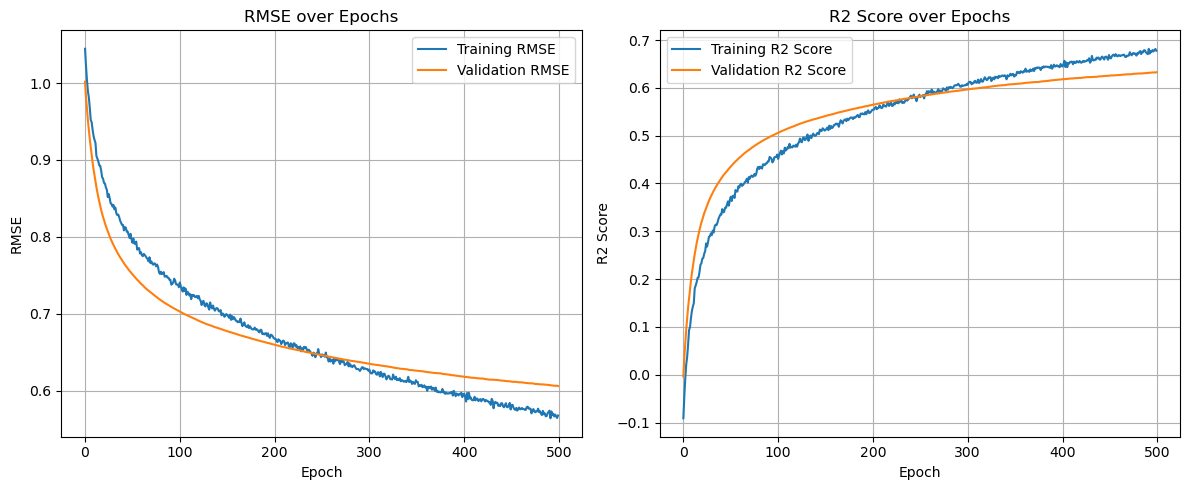

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_dropout.history['RootMeanSquaredError'], label='Training RMSE')
axes[0].plot(history_dropout.history['val_RootMeanSquaredError'], label='Validation RMSE')
axes[0].set_title('RMSE over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_dropout.history['r2_score'], label='Training R2 Score')
axes[1].plot(history_dropout.history['val_r2_score'], label='Validation R2 Score')
axes[1].set_title('R2 Score over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R2 Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


Observation : 
- It is observed that RMSE decreases with epoch.
- After using dropout , model is not showing overfit and underfit. Model is more generalize than without droupout.

### Test Data

### Load the data

In [13]:
df_test = pd.read_csv('test_data.csv')
X_test = df_test.drop('pIC50', axis=1)
Y_test = df_test['pIC50']

print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_test: (4235, 2052)
Shape of Y_test: (4235,)


Removing low variance and scalling the data as done in training data.

In [14]:
X_test_var = selection.transform(X_test)
X_test_scaled = scaler_x.transform(X_test_var)

print("Shape of X_test_scaled:", X_test_scaled.shape)


Shape of X_test_scaled: (4235, 511)


Evaluating the metrics same as done in training data

In [15]:

y_test_pred_scaled = model.predict(X_test_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

model_test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))
model_test_r2 = r2_score(Y_test, y_test_pred)


y_test_pred_dropout_scaled = model_dropout.predict(X_test_scaled)
y_test_pred_dropout = scaler_y.inverse_transform(y_test_pred_dropout_scaled)

model_test_rmse_dropout = np.sqrt(mean_squared_error(Y_test, y_test_pred_dropout))
model_test_r2_dropout = r2_score(Y_test, y_test_pred_dropout)

print("Model test Results:")
print("Test RMSE:", model_test_rmse)
print("Test R2:", model_test_r2)

print("Model with Dropout test Results:")
print("Test RMSE with Dropout:", model_test_rmse_dropout)
print("Test R2 with Dropout:", model_test_r2_dropout)

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model test Results:
Test RMSE: 0.9108442557194387
Test R2: 0.5740877874178896
Model with Dropout test Results:
Test RMSE with Dropout: 0.8505929672240689
Test R2 with Dropout: 0.6285713320147087


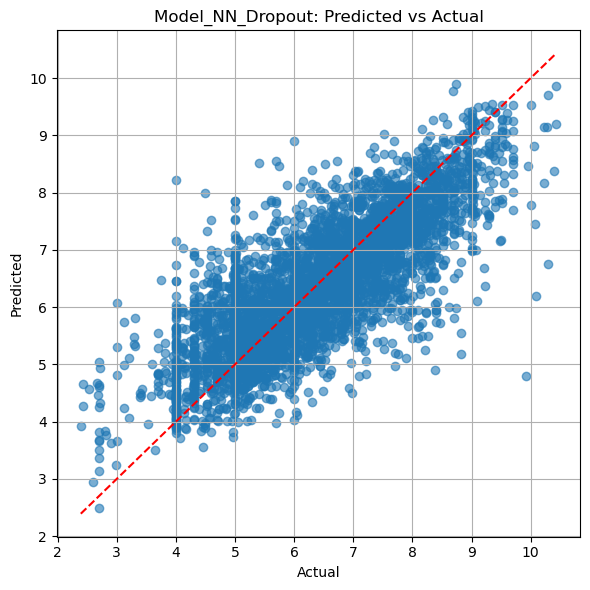

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, y_test_pred_dropout, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Model_NN_Dropout: Predicted vs Actual')
plt.grid(True)
plt.tight_layout()
plt.show()

This plot is also showing a clustered data but not idealy along the diagonal line. Model need more datapoints to train well.

In [17]:
def save_model_info(model_name, test_accuracy_rmse, r2 ):
    with open("model_info.txt", "a") as file:
        file.write(f"{model_name},{test_accuracy_rmse:.4f}, {r2:.4f}\n")

save_model_info("Model_NN", model_test_rmse, model_test_r2)
save_model_info("Model_NN_Dropout", model_test_rmse_dropout, model_test_r2_dropout)

## Appendix

AI tools are being used to optimize some codes, below interactions are being passed to it:
1. Correct the code
2. Optimize the code